# Model Factory Runs, Searches, and Diagnostics

This notebook is the operator and analysis surface for the Model Factory described in `docs/how-to/using-model-factory.md`. It can resolve a fully explicit experiment, preview or launch bounded searches, launch a baseline, confirm a winning configuration across seeds, inventory existing runs, compare paired validation episodes, visualize training/search behavior, inspect lineage, and diagnose common artifact/configuration failures.

The default action is **read-only** (`ACTION = 'inspect'`). Training actions are opt-in. Factory specs and persisted artifacts remain the source of truth; the notebook never uses sealed-test data during ordinary inspection or search.

## 1. Configure everything in one place

Every notebook control is declared below. Supported choices are written beside each field and are also rendered programmatically in the next section. `EXPERIMENT_CONFIG` is deliberately complete, including nullable/defaulted factory fields, so a run is not reproducible only through hidden library defaults.

Use `SPEC_SOURCE = 'template'` to start from an existing YAML/JSON file plus `SPEC_OVERRIDES`; use `'notebook'` for the fully explicit mapping below. `search_preview` is torch/corpus-free. `search`, `baseline`, and `confirm_seeds` may consume substantial compute.

In [4]:
from pathlib import Path
from pprint import pprint
import dataclasses
import html
import json
import math
import re
from collections import Counter, defaultdict
from datetime import datetime, timezone

import matplotlib.pyplot as plt
from IPython.display import HTML, display

# Locate the repository whether the kernel starts in the repo or notebooks/.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'pyproject.toml').is_file():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'pyproject.toml').is_file(), 'Start this notebook in the CCR repository.'

# ---- Action controls -------------------------------------------------------
ACTION_OPTIONS = ('inspect', 'baseline', 'search_preview', 'search', 'confirm_seeds')
ACTION = 'search'  # one of ACTION_OPTIONS; inspect is read-only
SPEC_SOURCE_OPTIONS = ('notebook', 'template')
SPEC_SOURCE = 'notebook'
SPEC_TEMPLATE_PATH = REPO_ROOT / 'specs' / 'crafter-baseline.yaml'
SPEC_OVERRIDES = []  # repeatable dotted.path=value strings, e.g. ['training.batch_size=64']

RUNS_ROOT = REPO_ROOT / 'runs'
CORPUS_ROOT = REPO_ROOT / 'corpora'
TRACE_DIR = None  # None uses the factory default
TRIAL_RUN_ID = 'new-baseline-population-1'  # None lets the factory allocate a unique id
NAMING_SEED = None  # None generates a fresh cosmetic display-name seed
HEARTBEAT_TIMEOUT_SECONDS = None  # None uses the state-machine default
EXPORT_PREDICTIONS = True
EXPORT_PREDICTIONS_MAX_EPISODES = 3

# ---- Fully explicit experiment configuration ------------------------------
# mode: fresh | clone | resume | fine_tune. Non-fresh modes require a parent block.
# backbone: gru | dilated_conv | transformer
# objective: windowed_rollout | autoregressive
# device: auto | cpu | cuda | cuda:<index> (or another valid torch device)
# checkpoint-selection mode: min | max; precision is currently recorded as fp32.
EXPERIMENT_CONFIG = {
    'format': 'model-factory-spec-v1',
    'organism': 'Crafter',
    'mode': 'clone',
    'parent': {
        'run_id': 'bridge-population-g1-r1-c10',
        'checkpoint': 'best-validation.pt',
        'sha256': 'cc89737de98ebccf42426ae6f10458f34f7713fcc9edcb02fe8355770453770f',
    },
    'data': {
        'corpus_id': 'crafter-generic-action-effects-v4',
        'world': 'crafter',
        'train_scenarios': ['motor_babbling_open', 'motor_babbling_walls', 'turn', 'blocked_forward', 'walk_forward_short', 'approach_entity'],
        'train_sessions': [],
        'validation_sessions': [],
        'test_sessions': [],
        'expected_pixel_source': 'crafter',
        'horizons_ticks': [1, 2],
        'quality_policy': {},
    },
    'model': {
        'backbone': 'dilated_conv',
        'latent_width': 128,
        'hidden_dim': 256,
        'action_embed_dim': 24,
        'reconstruction_size': 64,
        'context_length': 8,
         # n_layers is automatically covered to context length for dialated_conv, transformer is encoder layers 
         # n_heads is for transformer attention heads default 2
        #'backbone_kwargs': {'n_heads': 2, 'n_layers': 1},
        'backbone_kwargs': {},
    },
    'training': {
        'objective': 'windowed_rollout',
        'optimizer': {'name': 'adamw', 'lr': 0.002248110467780538, 'weight_decay': 2.5516692441336536e-05,},
        'batch_size': 32,
        'seed': 1,
        'rollout_frames': 8,
        'warmup_frames': 2,
        'scheduled_sampling_p': 0.11111555389456719,
        # Use complete ActionWorldModelConfig names; short aliases are ignored by the trainer.
        'loss_weights': {
            'pixel_loss_weight': 4.0,
            'latent_loss_weight': 1.0,
            'semantic_loss_weight': 1.0,
            'closed_loop_pixel_loss_weight': 0.6181269753996848,
            'closed_loop_latent_loss_weight': 0.8174918066144651,
            'direct_horizon_loss_weight': 1.0,
        },
        'checkpoint_selection_policy': {'metric': 'validation_loss', 'mode': 'min'},
        'device': 'auto',
        'precision': 'fp32',
        'determinism_policy': {'deterministic': True, 'seed': 0},
        'epoch_budget': 50,
        'step_budget': None,
        'scheduler': None,
        'max_training_seconds': 600.0,
        'checkpoint_cadence_epochs': 5,
        'ema_target_decay': None,
        'transition_balance_policy': {'stationary_cap': 0.009264325557644806,},
        'early_stopping_policy': {},
    },
    'evaluation': {
        'selection_metric': 'rollout.t+2.model_over_copy_last_mse',
        'gates': ['rollout_health', 'representation_collapse'],
        'confidence': 0.95,
    },
    'evolution': None,
}

# ---- Search controls (all run_successive_halving options) -----------------
SEARCH_CONFIG = {
    'schema': 'generic_action_effects_v1',
    'candidates': 24,
    'seed': 12,
    'method': 'lhs',  # lhs | random
    'budgets': (20, 50, 100),  # strictly increasing cumulative epoch rungs
    'halving_factor': 2,
    'run_id_prefix': 'bridge-population-g2',
    'champion_run_id': 'bridge-population-g1-r2-c10',
    'stage_budget_seconds': 5400.0,
    'min_episode_length': 26,
    'naming_seed': None,
}

# ---- Durable confirmation controls ----------------------------------------
CONFIRM_CONFIG = {
    'run_id': None,  # completed clone/fine_tune winner with metrics/comparison.json
    'organism': 'Crafter',
    'seeds': (11, 29, 47),  # at least two distinct seeds
    'minimum_practical_margin': 0.0,
    'naming_seed': None,
}

# ---- Analysis, comparison, and chart controls -----------------------------
ORGANISM_FILTER = 'Crafter'  # None scans every organism under RUNS_ROOT
RUN_IDS = (
    'notebook-search-6-r2-c6',
    'bridge-c9-genome-search6-arch',
    'Crafter-20260803T153337-61dd34',
) # empty selects the newest RUN_LIMIT runs; otherwise exact ids
RUN_LIMIT = 100
FOCUS_RUN_ID = 'Crafter-20260803T153337-61dd34'  # None chooses the newest selected run
COMPARE_BASELINE_RUN_ID = 'bridge-c9-genome-search6-arch'
COMPARE_CANDIDATE_RUN_IDS = (
    'Crafter-20260803T153337-61dd34',
)
COMPARISON_RESAMPLES = 10_000
COMPARISON_SEED = 0
SEARCH_CAMPAIGN_PREFIX = None  # None charts every detected <prefix>-rN-cN campaign
CHART_FIGSIZE = (10, 4.5)
CHART_DPI = 110
LOSS_CURVES = ('total_loss', 'pixel_loss', 'latent_loss', 'semantic_loss',
               'closed_loop_pixel_loss', 'closed_loop_latent_loss')
STALE_AFTER_SECONDS = 2400.0

assert ACTION in ACTION_OPTIONS
assert SPEC_SOURCE in SPEC_SOURCE_OPTIONS
plt.rcParams.update({'figure.dpi': CHART_DPI, 'axes.grid': True, 'grid.alpha': 0.25})
print(f'Repository: {REPO_ROOT}')
print(f'Action: {ACTION!r} (supported: {ACTION_OPTIONS})')

Repository: C:\Users\justi\Documents\CCR
Action: 'search' (supported: ('inspect', 'baseline', 'search_preview', 'search', 'confirm_seeds'))


## 2. Resolve the spec and display every supported option

This validates metric horizons before GPU work, materializes the complete immutable spec, displays every factory block/key, and renders the active genome schema with bounds, choices, defaults, mutation rules, and objective applicability. The final table lists every `ActionWorldModelConfig` field accepted by `training.loss_weights`; it is intentionally generated from the installed code so it cannot silently drift.

In [5]:
from cognitive_runtime.training.action_world_model import ActionWorldModelConfig
from cognitive_runtime.training.model_factory import (
    GENOME_SCHEMAS, OBJECTIVES, SEARCH_METHODS, VALID_MODES,
    apply_overrides, get_schema, load_spec, resolve,
)
from cognitive_runtime.training.model_factory.spec import (
    DATA_KEYS, EVALUATION_KEYS, EVOLUTION_KEYS, MODEL_KEYS, PARENT_KEYS,
    TOP_LEVEL_KEYS, TRAINING_KEYS,
)

def plain(value):
    if isinstance(value, dict) or hasattr(value, 'items'):
        return {key: plain(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(item) for item in value]
    return value

def show_table(rows, columns=None, limit=None):
    rows = list(rows)
    if limit is not None:
        rows = rows[:limit]
    if not rows:
        display(HTML('<em>No rows</em>'))
        return
    columns = list(columns or rows[0].keys())
    head = ''.join(f'<th>{html.escape(str(column))}</th>' for column in columns)
    body = []
    for row in rows:
        cells = ''.join(
            f'<td><code>{html.escape(str(row.get(column, "")))}</code></td>'
            for column in columns
        )
        body.append(f'<tr>{cells}</tr>')
    display(HTML('<div style="overflow:auto;max-height:520px"><table>'
                 f'<thead><tr>{head}</tr></thead><tbody>{"".join(body)}</tbody></table></div>'))

raw_spec = load_spec(SPEC_TEMPLATE_PATH) if SPEC_SOURCE == 'template' else plain(EXPERIMENT_CONFIG)
raw_spec = apply_overrides(raw_spec, SPEC_OVERRIDES)
resolved_spec = resolve(raw_spec)
resolved_config = plain(resolved_spec.to_dict())
schema = get_schema(SEARCH_CONFIG['schema'])

supported = [
    {'surface': 'notebook action', 'options': ACTION_OPTIONS},
    {'surface': 'spec source', 'options': SPEC_SOURCE_OPTIONS},
    {'surface': 'trial mode', 'options': VALID_MODES},
    {'surface': 'training objective', 'options': OBJECTIVES},
    {'surface': 'model backbone', 'options': ('gru', 'dilated_conv', 'transformer')},
    {'surface': 'training device', 'options': ('auto', 'cpu', 'cuda', 'cuda:<index>', '<torch device>')},
    {'surface': 'precision', 'options': ('fp32',)},
    {'surface': 'checkpoint selection', 'options': ('min', 'max')},
    {'surface': 'search method', 'options': SEARCH_METHODS},
    {'surface': 'genome schema', 'options': tuple(sorted(GENOME_SCHEMAS))},
]
show_table(supported, ('surface', 'options'))

key_catalog = [
    {'block': 'top level', 'keys': TOP_LEVEL_KEYS},
    {'block': 'parent', 'keys': PARENT_KEYS},
    {'block': 'data', 'keys': DATA_KEYS},
    {'block': 'model', 'keys': MODEL_KEYS},
    {'block': 'training', 'keys': TRAINING_KEYS},
    {'block': 'evaluation', 'keys': EVALUATION_KEYS},
    {'block': 'evolution', 'keys': EVOLUTION_KEYS},
]
show_table(key_catalog, ('block', 'keys'))

gene_rows = []
for name, gene in schema.genes.items():
    gene_rows.append({
        'gene': name, 'type': gene.type, 'bounds': gene.bounds, 'choices': gene.choices,
        'default': gene.default, 'mutation': gene.mutation.distribution,
        'sigma': gene.mutation.sigma,
        'active objectives': tuple(sorted(gene.active_objectives)) if gene.active_objectives else OBJECTIVES,
    })
show_table(gene_rows)

awm_rows = []
for field in dataclasses.fields(ActionWorldModelConfig):
    if field.default is not dataclasses.MISSING:
        default = field.default
    elif field.default_factory is not dataclasses.MISSING:
        default = field.default_factory()
    else:
        default = '<required>'
    awm_rows.append({'ActionWorldModelConfig field': field.name, 'default': default})
show_table(awm_rows)

print('Fully resolved experiment specification:')
pprint(resolved_config, sort_dicts=False)
print('training_contract_hash:', resolved_spec.training_contract_hash)

surface,options
notebook action,"('inspect', 'baseline', 'search_preview', 'search', 'confirm_seeds')"
spec source,"('notebook', 'template')"
trial mode,"('fresh', 'clone', 'resume', 'fine_tune')"
training objective,"('windowed_rollout', 'autoregressive')"
model backbone,"('gru', 'dilated_conv', 'transformer')"
training device,"('auto', 'cpu', 'cuda', 'cuda:<index>', '<torch device>')"
precision,"('fp32',)"
checkpoint selection,"('min', 'max')"
search method,"('random', 'lhs')"
genome schema,"('generic_action_effects_v1',)"


block,keys
top level,"('format', 'organism', 'mode', 'parent', 'data', 'model', 'training', 'evaluation', 'evolution')"
parent,"('run_id', 'checkpoint', 'sha256')"
data,"('corpus_id', 'world', 'train_scenarios', 'train_sessions', 'validation_sessions', 'test_sessions', 'expected_pixel_source', 'horizons_ticks', 'quality_policy')"
model,"('backbone', 'latent_width', 'hidden_dim', 'action_embed_dim', 'reconstruction_size', 'context_length', 'backbone_kwargs')"
training,"('objective', 'optimizer', 'batch_size', 'seed', 'rollout_frames', 'warmup_frames', 'scheduled_sampling_p', 'loss_weights', 'checkpoint_selection_policy', 'device', 'precision', 'determinism_policy', 'epoch_budget', 'step_budget', 'scheduler', 'max_training_seconds', 'checkpoint_cadence_epochs', 'ema_target_decay', 'transition_balance_policy', 'early_stopping_policy')"
evaluation,"('selection_metric', 'gates', 'confidence')"
evolution,"('generation', 'configuration_parents', 'weight_donor', 'genome_operator', 'mutations')"


gene,type,bounds,choices,default,mutation,sigma,active objectives
optimizer.lr,float,"(1e-05, 0.01)",None,0.0003,log_normal_perturb,0.3,"('windowed_rollout', 'autoregressive')"
optimizer.weight_decay,float,"(1e-07, 0.1)",None,1e-05,log_normal_perturb,0.5,"('windowed_rollout', 'autoregressive')"
scheduled_sampling_p,float,"(0.0, 0.5)",None,0.25,normal_perturb,0.05,"('windowed_rollout', 'autoregressive')"
loss_weights.closed_loop_pixel_loss_weight,float,"(0.0, 1.0)",None,0.25,normal_perturb,0.1,"('windowed_rollout',)"
loss_weights.closed_loop_latent_loss_weight,float,"(0.0, 1.0)",None,0.25,normal_perturb,0.1,"('windowed_rollout',)"
rollout_frames,int,None,"(4, 6, 8, 10, 12, 16)",8,categorical_resample,None,"('windowed_rollout', 'autoregressive')"
warmup_frames,int,None,"(1, 2, 3, 4, 6, 8)",3,categorical_resample,None,"('windowed_rollout', 'autoregressive')"
transition_balance_policy.stationary_cap,float,"(0.0, 1.0)",None,0.5,normal_perturb,0.1,"('windowed_rollout', 'autoregressive')"


ActionWorldModelConfig field,default
latent_width,32
hidden_dim,64
action_embed_dim,8
reconstruction_size,16
visual_architecture,spatial_residual_v1
change_mask_sparsity_weight,0.01
change_mask_supervision_weight,0.25
motion_pixel_loss_weight,4.0
change_mask_threshold,0.02
direct_horizon_loss_weight,1.0


Fully resolved experiment specification:
{'format': 'model-factory-spec-v1',
 'organism': 'Crafter',
 'mode': 'clone',
 'data': {'train_scenarios': ['motor_babbling_open',
                              'motor_babbling_walls',
                              'turn',
                              'blocked_forward',
                              'walk_forward_short',
                              'approach_entity'],
          'train_sessions': [],
          'validation_sessions': [],
          'test_sessions': [],
          'expected_pixel_source': 'crafter',
          'horizons_ticks': [1, 2],
          'quality_policy': {},
          'corpus_id': 'crafter-generic-action-effects-v4',
          'world': 'crafter'},
 'model': {'backbone': 'dilated_conv',
           'latent_width': 128,
           'hidden_dim': 256,
           'action_embed_dim': 24,
           'reconstruction_size': 64,
           'context_length': 8,
           'backbone_kwargs': {}},
 'training': {'objective': 'windowed_ro

## 3. Preview or execute the configured action

`inspect` performs no writes. `search_preview` prints exact deterministic proposals without loading a corpus or PyTorch. `baseline` and `search` execute the factory runner. `confirm_seeds` is the current Python-API path for durable seed confirmation and requires a completed clone/fine-tune winner.

In [6]:
from cognitive_runtime.training.model_factory import propose, run_successive_halving, run_trial
from cognitive_runtime.training.model_factory.confirmation import confirm_across_seeds

action_result = None
search_report = None
if ACTION == 'inspect':
    print('Read-only inspection selected; no trial or campaign launched.')
elif ACTION == 'search_preview':
    proposals = propose(
        resolved_spec, schema, SEARCH_CONFIG['candidates'], SEARCH_CONFIG['seed'],
        method=SEARCH_CONFIG['method'],
        min_episode_length=SEARCH_CONFIG['min_episode_length'],
        stage_budget_seconds=SEARCH_CONFIG['stage_budget_seconds'],
    )
    for index, candidate in enumerate(proposals):
        print(f'\n--- candidate {index} ---')
        pprint(plain(candidate.to_dict())['training'], sort_dicts=False)
    action_result = proposals
elif ACTION == 'baseline':
    action_result = run_trial(
        resolved_spec, root=RUNS_ROOT, corpus_root=CORPUS_ROOT, run_id=TRIAL_RUN_ID,
        naming_seed=NAMING_SEED, trace_dir=TRACE_DIR,
        heartbeat_timeout_seconds=HEARTBEAT_TIMEOUT_SECONDS,
        export_predictions=EXPORT_PREDICTIONS,
        export_predictions_max_episodes=EXPORT_PREDICTIONS_MAX_EPISODES,
    )
    print(action_result)
elif ACTION == 'search':
    search_report = run_successive_halving(
        resolved_spec, schema, budgets=SEARCH_CONFIG['budgets'],
        n=SEARCH_CONFIG['candidates'], seed=SEARCH_CONFIG['seed'],
        method=SEARCH_CONFIG['method'], halving_factor=SEARCH_CONFIG['halving_factor'],
        root=RUNS_ROOT, corpus_root=CORPUS_ROOT,
        run_id_prefix=SEARCH_CONFIG['run_id_prefix'],
        naming_seed=SEARCH_CONFIG['naming_seed'], trace_dir=TRACE_DIR,
        heartbeat_timeout_seconds=HEARTBEAT_TIMEOUT_SECONDS,
        champion_run_id=SEARCH_CONFIG['champion_run_id'],
        min_episode_length=SEARCH_CONFIG['min_episode_length'],
        stage_budget_seconds=SEARCH_CONFIG['stage_budget_seconds'],
    )
    action_result = search_report
    pprint(search_report.to_dict(), sort_dicts=False)
elif ACTION == 'confirm_seeds':
    if not CONFIRM_CONFIG['run_id']:
        raise ValueError('Set CONFIRM_CONFIG["run_id"] before ACTION="confirm_seeds".')
    action_result = confirm_across_seeds(
        CONFIRM_CONFIG['run_id'], CONFIRM_CONFIG['seeds'],
        organism=CONFIRM_CONFIG['organism'], root=RUNS_ROOT, corpus_root=CORPUS_ROOT,
        minimum_practical_margin=CONFIRM_CONFIG['minimum_practical_margin'],
        naming_seed=CONFIRM_CONFIG['naming_seed'], trace_dir=TRACE_DIR,
        heartbeat_timeout_seconds=HEARTBEAT_TIMEOUT_SECONDS,
    )
    pprint(action_result.to_dict(), sort_dicts=False)

frozen rollout detected: predictions barely vary across horizons (pred_disp=0.00018 vs target_disp=0.00737) -- the cortex has collapsed
frozen rollout detected: predictions barely vary across horizons (pred_disp=0.00017 vs target_disp=0.00737) -- the cortex has collapsed
frozen rollout detected: predictions barely vary across horizons (pred_disp=0.00026 vs target_disp=0.00747) -- the cortex has collapsed


{'format': 'model-factory-successive-halving-v1',
 'seed': 12,
 'method': 'lhs',
 'budgets': [20, 50, 100],
 'initial_candidates': 24,
 'halving_factor': 2,
 'rungs': [{'rung_index': 0,
            'budget': 20,
            'delta_epochs': 20,
            'results': [{'candidate_index': 0,
                         'run_id': 'bridge-population-g2-r0-c0',
                         'mode': 'fresh',
                         'budget': 20,
                         'epochs_executed': 0,
                         'state': 'failed',
                         'metric_value': None,
                         'gates': [],
                         'gate_passed': False,
                         'advanced': False,
                         'reason': 'candidate trial failed with ValueError: '
                                   'training corpus cannot support trial '
                                   'horizons [1, 2] ticks with warmup=6 and '
                                   'rollout=16: '
               

## 4. Inventory factory runs

The inventory tolerates partial and failed runs. It combines state, resolved spec, budget, execution provenance, validation evidence, and display-name artifacts without loading checkpoints. Search campaign/rung/candidate identities are inferred from the stable `*-r<rung>-c<candidate>` naming contract.

In [7]:
def read_json(path, default=None):
    try:
        with Path(path).open(encoding='utf-8') as handle:
            return json.load(handle)
    except (FileNotFoundError, json.JSONDecodeError, OSError):
        return {} if default is None else default

def parse_time(value):
    if not value:
        return None
    try:
        return datetime.fromisoformat(str(value).replace('Z', '+00:00'))
    except ValueError:
        return None

def nested_metric(validation, metric_path):
    if not metric_path:
        return None
    cursor = validation
    for part in metric_path.split('.'):
        if part.startswith('t+'):
            cursor = cursor.get('horizons', {}) if isinstance(cursor, dict) else {}
            part = part[2:]
        if not isinstance(cursor, dict):
            return None
        cursor = cursor.get(part, cursor.get(str(part)))
        if cursor is None:
            return None
    return float(cursor) if isinstance(cursor, (int, float)) else None

def flatten(mapping, prefix=''):
    rows = {}
    if isinstance(mapping, dict):
        for key, value in mapping.items():
            path = f'{prefix}.{key}' if prefix else str(key)
            rows.update(flatten(value, path))
    elif isinstance(mapping, list):
        rows[prefix] = tuple(mapping)
    else:
        rows[prefix] = mapping
    return rows

def run_payload(directory):
    directory = Path(directory)
    state = read_json(directory / 'state.json')
    spec = read_json(directory / 'trial_spec.json')
    budget = read_json(directory / 'metrics' / 'budget_report.json')
    validation = read_json(directory / 'metrics' / 'validation.json')
    execution = read_json(directory / 'execution.json')
    report = read_json(directory / 'experiment_report.json')
    lineage = read_json(directory / 'lineage.json')
    display_name = read_json(directory / 'display_name.json').get('display_name')
    selection_metric = validation.get('selection_metric') or spec.get('evaluation', {}).get('selection_metric')
    created, updated = parse_time(state.get('created_at')), parse_time(state.get('updated_at'))
    duration = (updated - created).total_seconds() if created and updated else None
    match = re.match(r'^(.*)-r(\d+)-c(\d+)$', directory.name)
    return {
        'directory': directory, 'run_id': directory.name, 'display_name': display_name,
        'state': state, 'spec': spec, 'budget': budget, 'validation': validation,
        'execution': execution, 'report': report, 'lineage': lineage,
        'status': state.get('state', 'missing_state'), 'reason': state.get('reason'),
        'mode': spec.get('mode'), 'selection_metric': selection_metric,
        'metric_value': nested_metric(validation, selection_metric),
        'created_at': state.get('created_at'), 'updated_at': state.get('updated_at'),
        'duration_seconds': duration, 'epochs': budget.get('epochs_recorded'),
        'training_seconds': budget.get('measured_training_seconds'),
        'tier': budget.get('tier'), 'device': execution.get('device'),
        'dirty': execution.get('dirty_tree'),
        'campaign': match.group(1) if match else None,
        'rung': int(match.group(2)) if match else None,
        'candidate': int(match.group(3)) if match else None,
    }

organism_dirs = [RUNS_ROOT / ORGANISM_FILTER] if ORGANISM_FILTER else [p for p in RUNS_ROOT.iterdir() if p.is_dir() and p.name != 'traces']
all_run_dirs = [p for organism_dir in organism_dirs if organism_dir.is_dir() for p in organism_dir.iterdir() if p.is_dir()]
runs = [run_payload(path) for path in all_run_dirs]
runs.sort(key=lambda row: row['updated_at'] or row['created_at'] or '', reverse=True)
if RUN_IDS:
    wanted = set(RUN_IDS)
    runs = [row for row in runs if row['run_id'] in wanted]
else:
    runs = runs[:RUN_LIMIT]
runs_by_id = {row['run_id']: row for row in runs}

inventory_rows = [{
    'run_id': row['run_id'], 'name': row['display_name'], 'state': row['status'],
    'mode': row['mode'], 'metric': row['metric_value'], 'epochs': row['epochs'],
    'train_s': row['training_seconds'], 'device': row['device'], 'dirty': row['dirty'],
    'campaign': row['campaign'], 'rung': row['rung'], 'candidate': row['candidate'],
    'updated': row['updated_at'],
} for row in runs]
show_table(inventory_rows)
print(f'Selected {len(runs)} run(s) from {len(all_run_dirs)} discovered directories.')

run_id,name,state,mode,metric,epochs,train_s,device,dirty,campaign,rung,candidate,updated
Crafter-20260803T153337-61dd34,vibrant-morse-minsky,completed,clone,0.9991661499978061,50,253.10636069998145,auto,True,None,None,None,2026-08-03T22:38:42.559131+00:00
bridge-c9-genome-search6-arch,relaxed-morse,completed,fresh,0.9081176729109385,50,265.304634300177,auto,True,None,None,None,2026-08-03T21:48:59.580240+00:00
notebook-search-6-r2-c6,stoic-minsky,completed,fine_tune,0.9873796886689579,50,291.0050391998375,auto,True,notebook-search-6,2,6,2026-08-03T20:46:03.249467+00:00


Selected 3 run(s) from 125 discovered directories.


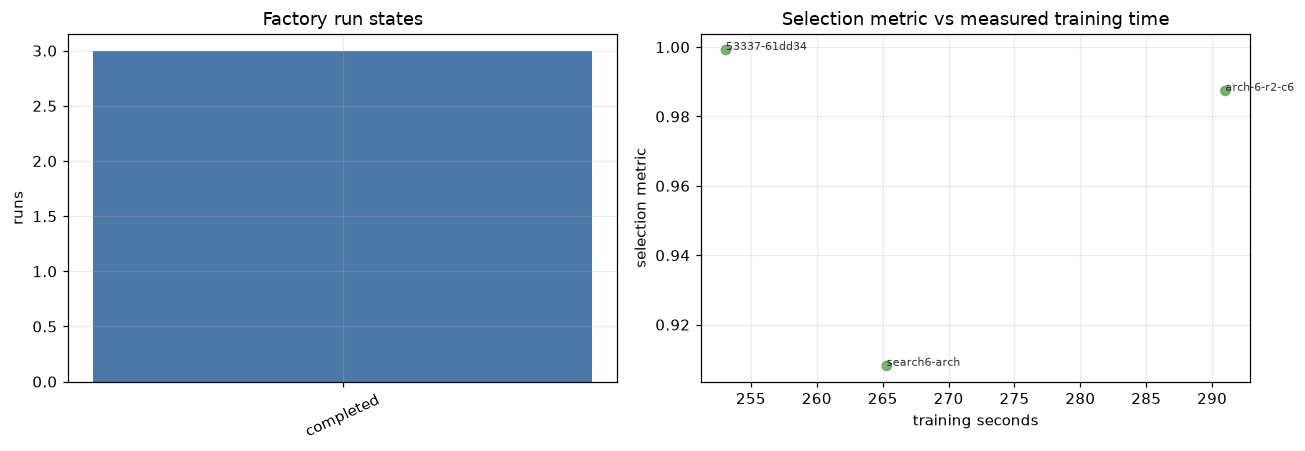

In [8]:
# Fleet view: state counts and measured training time vs. selection metric.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
state_counts = Counter(row['status'] for row in runs)
axes[0].bar(state_counts.keys(), state_counts.values(), color='#4C78A8')
axes[0].set(title='Factory run states', ylabel='runs')
axes[0].tick_params(axis='x', rotation=25)

plotted = [row for row in runs if row['metric_value'] is not None and row['training_seconds'] is not None]
colors = ['#59A14F' if row['status'] == 'completed' else '#E15759' for row in plotted]
axes[1].scatter([row['training_seconds'] for row in plotted], [row['metric_value'] for row in plotted], c=colors, alpha=.8)
for row in plotted:
    axes[1].annotate(row['run_id'][-12:], (row['training_seconds'], row['metric_value']), fontsize=7, alpha=.8)
axes[1].set(title='Selection metric vs measured training time', xlabel='training seconds', ylabel='selection metric')
plt.tight_layout(); plt.show()

## 5. Diagnose artifact and configuration issues

Checks cover terminal state, artifact completeness, heartbeat freshness, metric/horizon alignment, checkpoint sidecars, rollout health, promotion verdicts, source dirtiness, ignored loss-weight aliases, and settings currently recorded in the contract but not wired into trainer behavior. Findings are evidence, not automatic repair actions.

In [9]:
AWM_FIELDS = {field.name for field in dataclasses.fields(ActionWorldModelConfig)}
TERMINAL_STATES = {'completed', 'budget_exceeded', 'failed', 'cancelled'}

def finding(run_id, severity, check, detail):
    return {'run_id': run_id, 'severity': severity, 'check': check, 'detail': detail}

def diagnose_run(row):
    run_id, directory = row['run_id'], row['directory']
    findings = []
    required = ('trial_spec.json', 'state.json', 'contracts.json', 'execution.json', 'lineage.json')
    for relative in required:
        if not (directory / relative).is_file():
            findings.append(finding(run_id, 'error', 'missing artifact', relative))
    state = row['state']
    status = row['status']
    if status in {'failed', 'cancelled', 'budget_exceeded'}:
        findings.append(finding(run_id, 'error' if status == 'failed' else 'warning', 'terminal state', f'{status}: {row["reason"]}'))
    elif status not in TERMINAL_STATES:
        heartbeat = read_json(directory / 'heartbeat.json')
        stamp = parse_time(heartbeat.get('at') or heartbeat.get('updated_at'))
        if stamp:
            age = (datetime.now(timezone.utc) - stamp.astimezone(timezone.utc)).total_seconds()
            if age > STALE_AFTER_SECONDS:
                findings.append(finding(run_id, 'error', 'stale heartbeat', f'{age:.0f}s old; threshold={STALE_AFTER_SECONDS:.0f}s'))
        else:
            findings.append(finding(run_id, 'warning', 'heartbeat', 'active/nonterminal run has no readable heartbeat timestamp'))
    if status == 'completed':
        for relative in ('metrics/validation.json', 'metrics/budget_report.json', 'experiment_report.json',
                         'checkpoints/last.pt', 'checkpoints/last.pt.json',
                         'checkpoints/best-validation.pt', 'checkpoints/best-validation.pt.json'):
            if not (directory / relative).is_file():
                findings.append(finding(run_id, 'error', 'completed artifact missing', relative))
    spec = row['spec']
    metric = row['selection_metric'] or ''
    requested_horizons = [int(value) for value in re.findall(r't\+(\d+)', metric)]
    declared_horizons = spec.get('data', {}).get('horizons_ticks', [])
    missing_horizons = [value for value in requested_horizons if value not in declared_horizons]
    if missing_horizons:
        findings.append(finding(run_id, 'error', 'metric horizon', f'{metric} requests {missing_horizons}; declared={declared_horizons}'))
    if row['validation'] and metric and row['metric_value'] is None:
        findings.append(finding(run_id, 'error', 'selection metric', f'{metric!r} is not resolvable in metrics/validation.json'))
    weights = spec.get('training', {}).get('loss_weights', {})
    ignored = sorted(set(weights) - AWM_FIELDS)
    if ignored:
        findings.append(finding(run_id, 'warning', 'ignored loss-weight keys', f'{ignored}; use complete ActionWorldModelConfig field names'))
    optimizer = spec.get('training', {}).get('optimizer', {})
    if optimizer.get('name') not in (None, 'adam') or optimizer.get('weight_decay') not in (None, 0, 0.0):
        findings.append(finding(run_id, 'warning', 'optimizer wiring', 'name/weight_decay are contract evidence, but the current trainer constructs torch.optim.Adam with lr only'))
    if spec.get('training', {}).get('transition_balance_policy'):
        findings.append(finding(run_id, 'warning', 'transition balance wiring', 'policy is recorded but currently has no trainer consumer'))
    if row['execution'].get('dirty_tree'):
        findings.append(finding(run_id, 'info', 'source provenance', 'run was executed from a dirty worktree'))
    health = row['validation'].get('rollout_health', {})
    if health and health.get('state') not in (None, 'healthy'):
        findings.append(finding(run_id, 'warning', 'rollout health', f"state={health.get('state')}, dispersion_ratio={health.get('dispersion_ratio')}"))
    verdict = row['report'].get('promotion_verdict', {})
    if verdict and not verdict.get('promoted', False):
        findings.append(finding(run_id, 'info', 'promotion hold', '; '.join(verdict.get('reasons', []))))
    if not findings:
        findings.append(finding(run_id, 'ok', 'diagnostics', 'no issues found by notebook checks'))
    return findings

diagnostic_rows = [item for row in runs for item in diagnose_run(row)]
severity_order = {'error': 0, 'warning': 1, 'info': 2, 'ok': 3}
diagnostic_rows.sort(key=lambda item: (severity_order[item['severity']], item['run_id'], item['check']))
show_table(diagnostic_rows, ('severity', 'run_id', 'check', 'detail'))
print('Finding counts:', dict(Counter(row['severity'] for row in diagnostic_rows)))

severity,run_id,check,detail
warning,Crafter-20260803T153337-61dd34,optimizer wiring,"name/weight_decay are contract evidence, but the current trainer constructs torch.optim.Adam with lr only"
warning,Crafter-20260803T153337-61dd34,transition balance wiring,policy is recorded but currently has no trainer consumer
warning,bridge-c9-genome-search6-arch,optimizer wiring,"name/weight_decay are contract evidence, but the current trainer constructs torch.optim.Adam with lr only"
warning,bridge-c9-genome-search6-arch,transition balance wiring,policy is recorded but currently has no trainer consumer
warning,notebook-search-6-r2-c6,optimizer wiring,"name/weight_decay are contract evidence, but the current trainer constructs torch.optim.Adam with lr only"
warning,notebook-search-6-r2-c6,transition balance wiring,policy is recorded but currently has no trainer consumer
info,Crafter-20260803T153337-61dd34,promotion hold,t+1 has no evaluable cow-absent samples; t+2 has no evaluable cow-absent samples
info,Crafter-20260803T153337-61dd34,source provenance,run was executed from a dirty worktree
info,bridge-c9-genome-search6-arch,promotion hold,t+1 has no evaluable cow-absent samples; t+2 has no evaluable cow-absent samples
info,bridge-c9-genome-search6-arch,source provenance,run was executed from a dirty worktree


Finding counts: {'warning': 6, 'info': 6}


## 6. Inspect one run deeply

Select `FOCUS_RUN_ID` above, or leave it `None` for the newest selected run. This section shows state transitions, provenance, hashes/lineage, training curves, and rollout error by horizon. Missing artifacts produce empty views instead of breaking the rest of the notebook.

Focus: Crafter-20260803T153337-61dd34 (vibrant-morse-minsky)


at,from,to,reason
2026-08-03T22:33:38.694159+00:00,None,queued,queued
2026-08-03T22:33:38.701824+00:00,queued,running,None
2026-08-03T22:38:42.559131+00:00,running,completed,completed


{'state': 'completed',
 'reason': 'completed',
 'mode': 'clone',
 'selection_metric': 'rollout.t+2.model_over_copy_last_mse',
 'metric_value': 0.9991661499978061,
 'budget': {'completion_status': 'completed',
            'epochs_recorded': 50,
            'format': 'model-factory-budget-report-v1',
            'hardware_profile': {'cuda_available': True,
                                 'cuda_device': 'NVIDIA GeForce RTX 3090',
                                 'cuda_device_count': 1,
                                 'default_dtype': 'torch.float32',
                                 'threads': 10,
                                 'torch_version': '2.13.0+cu126'},
            'max_training_seconds': 600.0,
            'measured_training_seconds': 253.10636069998145,
            'precision': 'fp32',
            'tier': 'fast',
            'timing_policy_version': 'model-factory-budget-timing-v1',
            'total_epochs': 50,
            'total_trial_seconds': 296.3405171999475,
       

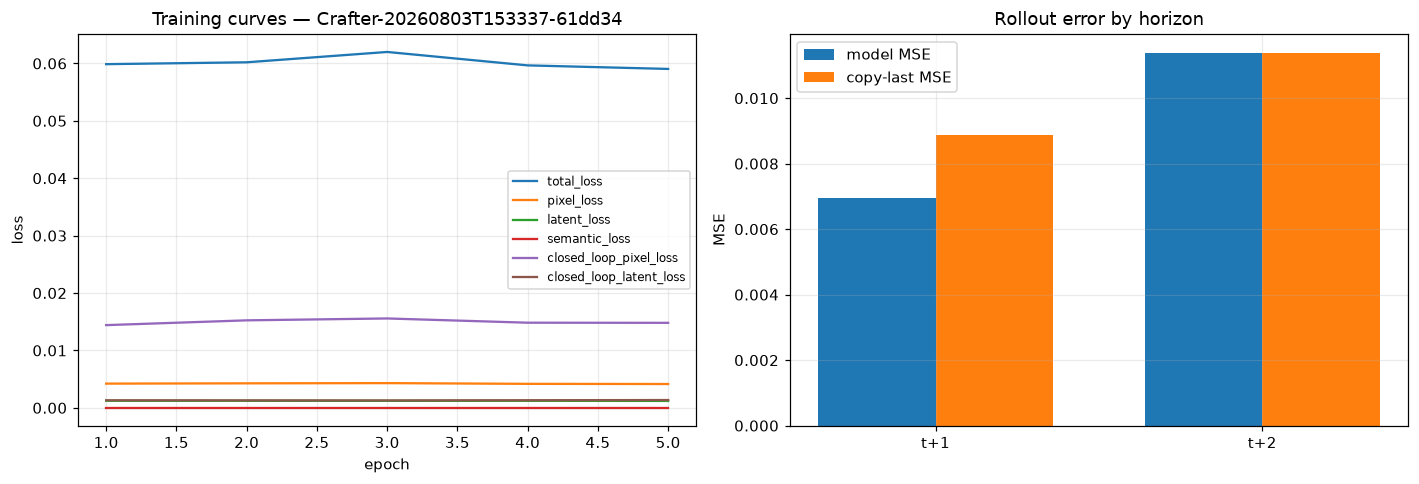

In [10]:
focus = runs_by_id.get(FOCUS_RUN_ID) if FOCUS_RUN_ID else (runs[0] if runs else None)
if focus is None:
    print('No focus run available.')
else:
    print(f"Focus: {focus['run_id']} ({focus['display_name']})")
    show_table(focus['state'].get('history', []), ('at', 'from', 'to', 'reason'))
    summary = {
        'state': focus['status'], 'reason': focus['reason'], 'mode': focus['mode'],
        'selection_metric': focus['selection_metric'], 'metric_value': focus['metric_value'],
        'budget': focus['budget'], 'source': focus['execution'].get('source'),
        'lineage': focus['lineage'],
        'contract_hashes': {key: value for key, value in read_json(focus['directory'] / 'contracts.json').items() if key.endswith('_hash')},
    }
    pprint(summary, sort_dicts=False)

    curves = focus['report'].get('training_stats', {}).get('loss_curves', {})
    rollout = focus['validation'].get('rollout', {})
    horizons = rollout.get('horizons', {})
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for name in LOSS_CURVES:
        values = curves.get(name)
        if values:
            axes[0].plot(range(1, len(values) + 1), values, label=name)
    axes[0].set(title=f"Training curves — {focus['run_id']}", xlabel='epoch', ylabel='loss')
    if axes[0].lines:
        axes[0].legend(fontsize=8)
    horizon_keys = sorted(horizons, key=lambda value: int(value))
    model_mse = [horizons[key].get('model_mse', math.nan) for key in horizon_keys]
    copy_mse = [horizons[key].get('copy_last_mse', math.nan) for key in horizon_keys]
    x = list(range(len(horizon_keys)))
    axes[1].bar([value - .18 for value in x], model_mse, width=.36, label='model MSE')
    axes[1].bar([value + .18 for value in x], copy_mse, width=.36, label='copy-last MSE')
    axes[1].set_xticks(x, [f't+{key}' for key in horizon_keys])
    axes[1].set(title='Rollout error by horizon', ylabel='MSE')
    if horizon_keys:
        axes[1].legend()
    plt.tight_layout(); plt.show()

## 7. Paired A/B comparison and exact configuration diff

Set `COMPARE_BASELINE_RUN_ID` and one or more `COMPARE_CANDIDATE_RUN_IDS`. Comparisons use matching frozen validation episode IDs and raw per-episode model MSE at the selection horizon. Negative candidate-minus-baseline deltas are improvements. The config table exposes every changed resolved field so accidental multi-variable trials are obvious.

candidate,status,episodes,mean_delta,win_rate,bootstrap_interval,permutation_interval
Crafter-20260803T153337-61dd34,evaluable,6,0.0012712082420519497,0.5,"(-0.00030810176624833607, 0.003052936908283879)","(-0.0004318010531742984, 0.002974217537278198)"


candidate,path,baseline,candidate value
Crafter-20260803T153337-61dd34,evolution.configuration_parents,None,"('notebook-search-6-r2-c6', 'bridge-c9-genome-search6-arch')"
Crafter-20260803T153337-61dd34,evolution.generation,None,1
Crafter-20260803T153337-61dd34,evolution.genome_operator,None,uniform_crossover_v1
Crafter-20260803T153337-61dd34,evolution.mutations,None,"('optimizer.lr', 'optimizer.weight_decay')"
Crafter-20260803T153337-61dd34,evolution.weight_donor,None,bridge-c9-genome-search6-arch
Crafter-20260803T153337-61dd34,mode,fresh,clone
Crafter-20260803T153337-61dd34,parent.checkpoint,None,best-validation.pt
Crafter-20260803T153337-61dd34,parent.run_id,None,bridge-c9-genome-search6-arch
Crafter-20260803T153337-61dd34,parent.sha256,None,a43762a13507c8eee6d18fc780a1623cc286111223581144625e393717848e2c
Crafter-20260803T153337-61dd34,training.loss_weights.closed_loop_pixel_loss_weight,0.6181269753996848,0.01384847110295285


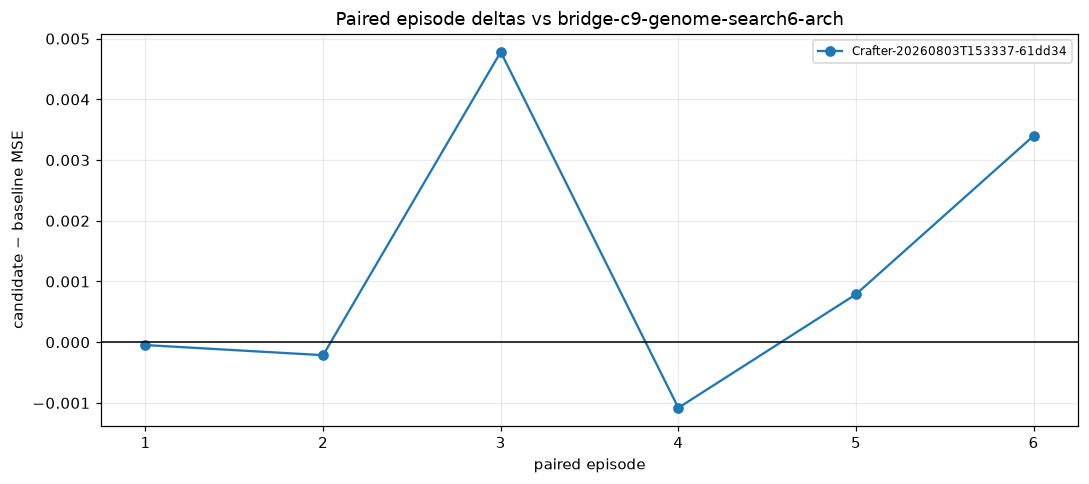

In [11]:
from cognitive_runtime.training.model_factory import compare_paired_episodes

def comparison_inputs(row):
    validation = row['validation']
    metric = row['selection_metric'] or ''
    parts = metric.split('.')
    mode = parts[0] if parts and parts[0] in ('direct', 'rollout') else validation.get('rollout', {}).get('prediction_mode', 'rollout')
    horizon_match = re.search(r't\+(\d+)', metric)
    if not horizon_match:
        raise ValueError(f'{row["run_id"]}: comparison requires a t+N selection metric; got {metric!r}')
    horizon = horizon_match.group(1)
    errors = validation.get(mode, {}).get('per_episode_model_mse', {}).get(horizon)
    episode_ids = validation.get('episode_ids')
    if errors is None or episode_ids is None:
        raise ValueError(f'{row["run_id"]}: missing per-episode {mode} t+{horizon} evidence')
    return errors, episode_ids, metric

comparison_rows, config_diff_rows, delta_series = [], [], []
if not COMPARE_BASELINE_RUN_ID or not COMPARE_CANDIDATE_RUN_IDS:
    print('Set COMPARE_BASELINE_RUN_ID and COMPARE_CANDIDATE_RUN_IDS to run paired comparisons.')
else:
    baseline = runs_by_id.get(COMPARE_BASELINE_RUN_ID) or run_payload(RUNS_ROOT / (ORGANISM_FILTER or 'Crafter') / COMPARE_BASELINE_RUN_ID)
    baseline_errors, baseline_ids, primary_metric = comparison_inputs(baseline)
    base_flat = flatten(baseline['spec'])
    for candidate_id in COMPARE_CANDIDATE_RUN_IDS:
        candidate = runs_by_id.get(candidate_id) or run_payload(RUNS_ROOT / (ORGANISM_FILTER or 'Crafter') / candidate_id)
        candidate_errors, candidate_ids, candidate_metric = comparison_inputs(candidate)
        if candidate_metric != primary_metric:
            raise ValueError(f'metric mismatch: {primary_metric!r} != {candidate_metric!r}')
        result = compare_paired_episodes(
            candidate_errors, baseline_errors, candidate_episode_ids=candidate_ids,
            baseline_episode_ids=baseline_ids, primary_metric=primary_metric,
            confidence=float(candidate['spec'].get('evaluation', {}).get('confidence', .95)),
            resamples=COMPARISON_RESAMPLES, seed=COMPARISON_SEED,
        )
        comparison_rows.append({
            'candidate': candidate_id, 'status': result.status, 'episodes': result.episode_count,
            'mean_delta': result.mean_delta, 'win_rate': result.win_rate,
            'bootstrap_interval': result.bootstrap_interval,
            'permutation_interval': result.permutation_interval,
        })
        delta_series.append((candidate_id, list(result.deltas)))
        candidate_flat = flatten(candidate['spec'])
        for path in sorted(set(base_flat) | set(candidate_flat)):
            if base_flat.get(path) != candidate_flat.get(path):
                config_diff_rows.append({'candidate': candidate_id, 'path': path, 'baseline': base_flat.get(path), 'candidate value': candidate_flat.get(path)})
    show_table(comparison_rows)
    show_table(config_diff_rows)
    fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
    for candidate_id, deltas in delta_series:
        ax.plot(range(1, len(deltas) + 1), deltas, marker='o', label=candidate_id)
    ax.axhline(0, color='black', linewidth=1)
    ax.set(title=f'Paired episode deltas vs {COMPARE_BASELINE_RUN_ID}', xlabel='paired episode', ylabel='candidate − baseline MSE')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 8. Analyze successive-halving searches

Search runs are grouped by their stable prefix. The first chart shows candidate selection metric by rung and status. The schema panels relate every declared gene to the measured metric, making bounded-space trends and dead/unwired genes easier to spot. Use `SEARCH_CAMPAIGN_PREFIX` to isolate a campaign.

Detected campaigns: ['notebook-search-6']


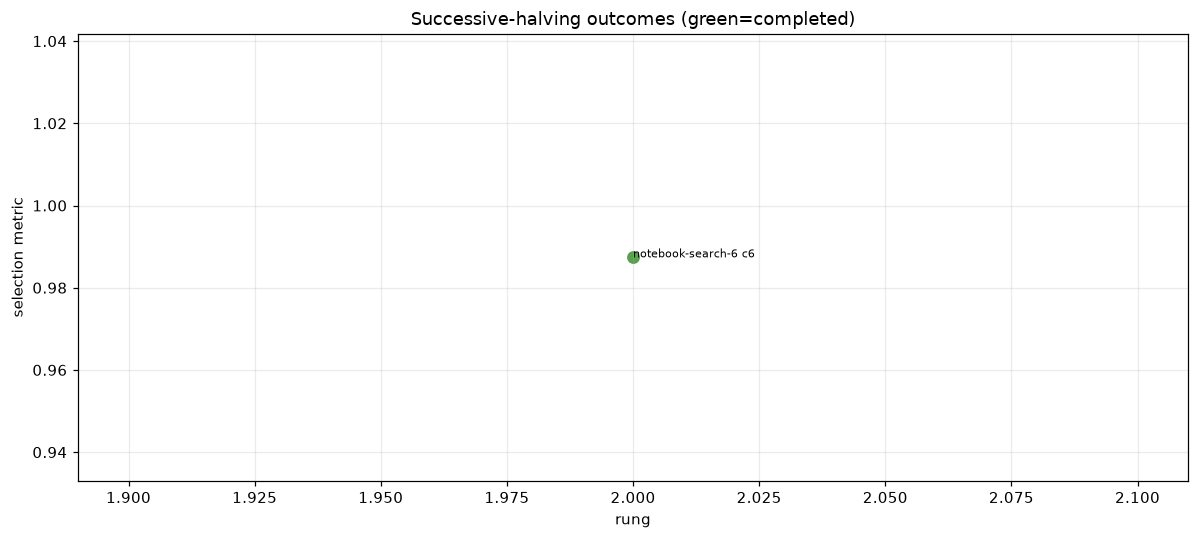

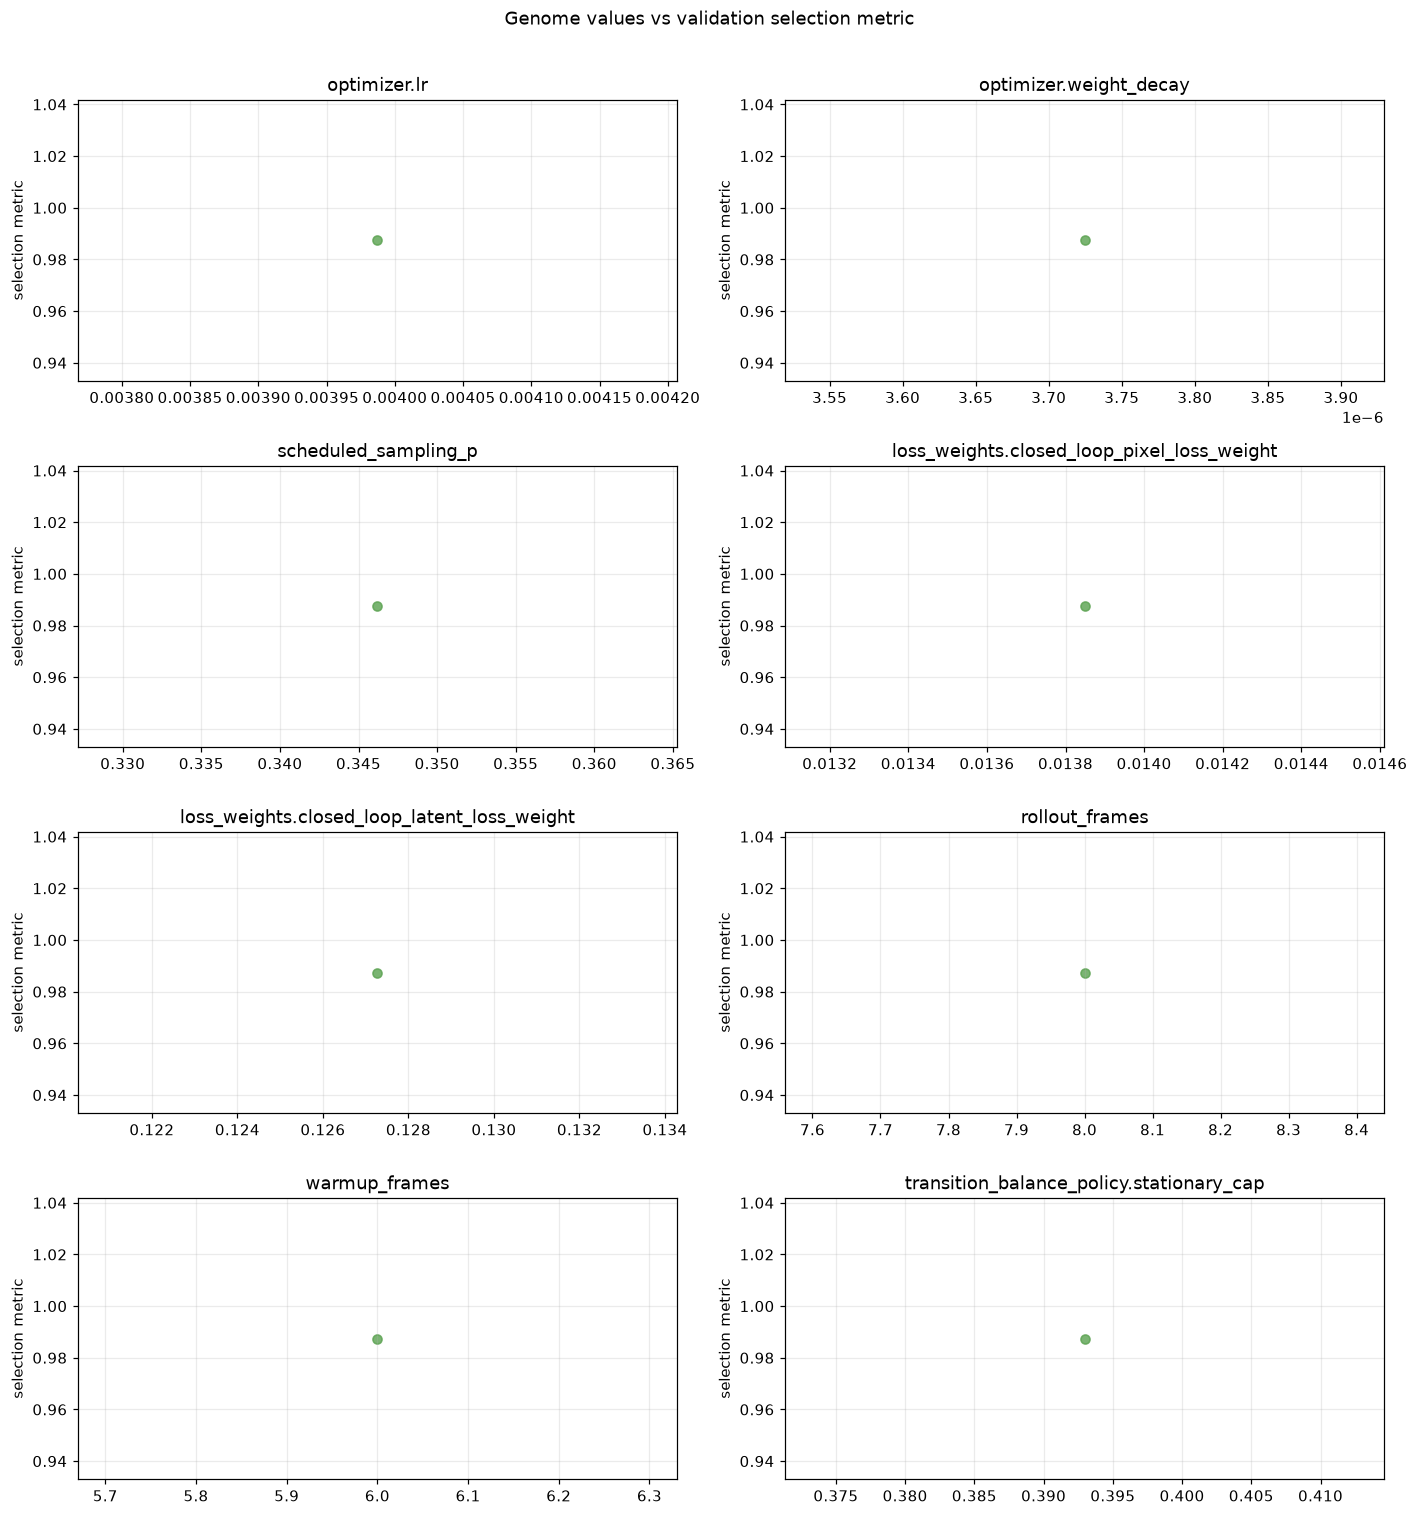

In [12]:
search_runs = [row for row in runs if row['campaign'] and (SEARCH_CAMPAIGN_PREFIX is None or row['campaign'] == SEARCH_CAMPAIGN_PREFIX)]
campaigns = sorted({row['campaign'] for row in search_runs})
print('Detected campaigns:', campaigns)
if not search_runs:
    print('No search runs in the selected inventory. Increase RUN_LIMIT or set RUN_IDS explicitly.')
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    for row in sorted(search_runs, key=lambda item: (item['campaign'], item['candidate'], item['rung'])):
        if row['metric_value'] is None:
            continue
        color = '#59A14F' if row['status'] == 'completed' else '#E15759'
        ax.scatter(row['rung'], row['metric_value'], color=color, s=55)
        ax.annotate(f"{row['campaign']} c{row['candidate']}", (row['rung'], row['metric_value']), fontsize=7)
    ax.set(title='Successive-halving outcomes (green=completed)', xlabel='rung', ylabel='selection metric')
    plt.tight_layout(); plt.show()

    genes = list(schema.genes)
    cols = 2
    rows_count = math.ceil(len(genes) / cols)
    fig, axes = plt.subplots(rows_count, cols, figsize=(13, 3.4 * rows_count), squeeze=False)
    for axis, gene_name in zip(axes.flat, genes):
        points = []
        for row in search_runs:
            value = flatten(row['spec'].get('training', {})).get(gene_name)
            if value is not None and row['metric_value'] is not None:
                points.append((value, row['metric_value'], row['status']))
        if points:
            values = [point[0] for point in points]
            if all(isinstance(value, (int, float)) for value in values):
                x_values = values
            else:
                categories = {value: index for index, value in enumerate(sorted(set(values), key=str))}
                x_values = [categories[value] for value in values]
                axis.set_xticks(list(categories.values()), [str(value) for value in categories], rotation=20)
            axis.scatter(x_values, [point[1] for point in points],
                         c=['#59A14F' if point[2] == 'completed' else '#E15759' for point in points], alpha=.8)
        axis.set(title=gene_name, ylabel='selection metric')
    for axis in list(axes.flat)[len(genes):]:
        axis.set_visible(False)
    fig.suptitle('Genome values vs validation selection metric', y=1.01)
    plt.tight_layout(); plt.show()

## 9. Lineage and artifact handoff

The final cell walks configuration parents/weight donors from persisted lineage manifests, prints a compact tree, and lists the exact CLI commands for independent inspection. Promotion, sealed testing, and durable promotion remain explicit actions outside ordinary notebook analysis.

In [13]:
def lineage_parent_ids(lineage):
    parent_ids = []
    parent = lineage.get('parent')
    if isinstance(parent, dict) and parent.get('run_id'):
        parent_ids.append(parent['run_id'])
    elif isinstance(parent, str):
        parent_ids.append(parent)
    for value in lineage.get('configuration_parents', []) or []:
        parent_id = value.get('run_id') if isinstance(value, dict) else value
        if parent_id:
            parent_ids.append(parent_id)
    donor = lineage.get('weight_donor')
    donor_id = donor.get('run_id') if isinstance(donor, dict) else donor
    if donor_id:
        parent_ids.append(donor_id)
    return tuple(dict.fromkeys(parent_ids))

def print_lineage(run_id, organism, indent='', seen=None):
    seen = set() if seen is None else seen
    marker = ' (cycle)' if run_id in seen else ''
    print(f'{indent}{run_id}{marker}')
    if run_id in seen:
        return
    seen.add(run_id)
    directory = RUNS_ROOT / organism / run_id
    for parent_id in lineage_parent_ids(read_json(directory / 'lineage.json')):
        print_lineage(parent_id, organism, indent + '  └─ ', seen)

if focus:
    organism = focus['spec'].get('organism', ORGANISM_FILTER or 'Crafter')
    print('Persisted lineage:')
    print_lineage(focus['run_id'], organism)
    print('\nUseful commands:')
    print(f'ccr factory show {focus["run_id"]} --root {RUNS_ROOT}')
    print(f'ccr factory lineage {focus["run_id"]} --root {RUNS_ROOT}')
    print(f'ccr factory promote {focus["run_id"]} --root {RUNS_ROOT}')
    print('# After successful multi-seed confirmation only:')
    print(f'ccr factory test {focus["run_id"]} --root {RUNS_ROOT} --corpus-root {CORPUS_ROOT}')
    print(f'ccr factory promote {focus["run_id"]} --durable --root {RUNS_ROOT}')
    print('\nArtifact directory:', focus['directory'])
else:
    print('No focus run available for lineage inspection.')

Persisted lineage:
Crafter-20260803T153337-61dd34
  └─ bridge-c9-genome-search6-arch
  └─ notebook-search-6-r2-c6
  └─   └─ notebook-search-6-r1-c6
  └─   └─   └─ notebook-search-6-r0-c6

Useful commands:
ccr factory show Crafter-20260803T153337-61dd34 --root C:\Users\justi\Documents\CCR\runs
ccr factory lineage Crafter-20260803T153337-61dd34 --root C:\Users\justi\Documents\CCR\runs
ccr factory promote Crafter-20260803T153337-61dd34 --root C:\Users\justi\Documents\CCR\runs
# After successful multi-seed confirmation only:
ccr factory test Crafter-20260803T153337-61dd34 --root C:\Users\justi\Documents\CCR\runs --corpus-root C:\Users\justi\Documents\CCR\corpora
ccr factory promote Crafter-20260803T153337-61dd34 --durable --root C:\Users\justi\Documents\CCR\runs

Artifact directory: C:\Users\justi\Documents\CCR\runs\Crafter\Crafter-20260803T153337-61dd34
